In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import numpy as np

In [2]:
velocities = pd.read_csv('rotation_velocity_sweep_results.csv')
velocities.head()

,mesh_size,radius,rotation_velocity,sample_count,max_error,mean_error,rms_error,max_speed_error,max_radius_based_speed_error
0,1000,0.5,10.0,1280,9.689204e-07,3.194633e-07,4.024405e-07,9.689204e-07,9.689204e-07
1,1000,0.5,25.0,1280,2.422301e-06,7.986583e-07,1.006101e-06,2.422301e-06,2.422301e-06
2,1000,0.5,50.0,1280,4.844602e-06,1.597317e-06,2.012202e-06,4.844602e-06,4.844602e-06
3,1000,0.5,100.0,1280,9.689204e-06,3.194633e-06,4.024405e-06,9.689204e-06,9.689204e-06
4,1000,0.5,200.0,1280,1.937841e-05,6.389267e-06,8.048809e-06,1.937841e-05,1.937841e-05


In [4]:
velocities_sp = pd.read_csv('rotation_velocity_sweep_results_new_sp.csv')

In [5]:
velocities['sample_count'].unique()

array([ 1280,  5120, 20480])

In [6]:
velocities_small = velocities[velocities['sample_count'] == 1280]
velocities_medium = velocities[velocities['sample_count'] == 5120]
velocities_large = velocities[velocities['sample_count'] == 20480]

velocities_small_sp = velocities_sp[velocities_sp['sample_count'] == 1280]
velocities_medium_sp = velocities_sp[velocities_sp['sample_count'] == 5120]
velocities_large_sp = velocities_sp[velocities_sp['sample_count'] == 20480]

In [7]:
import cmasher as cmr

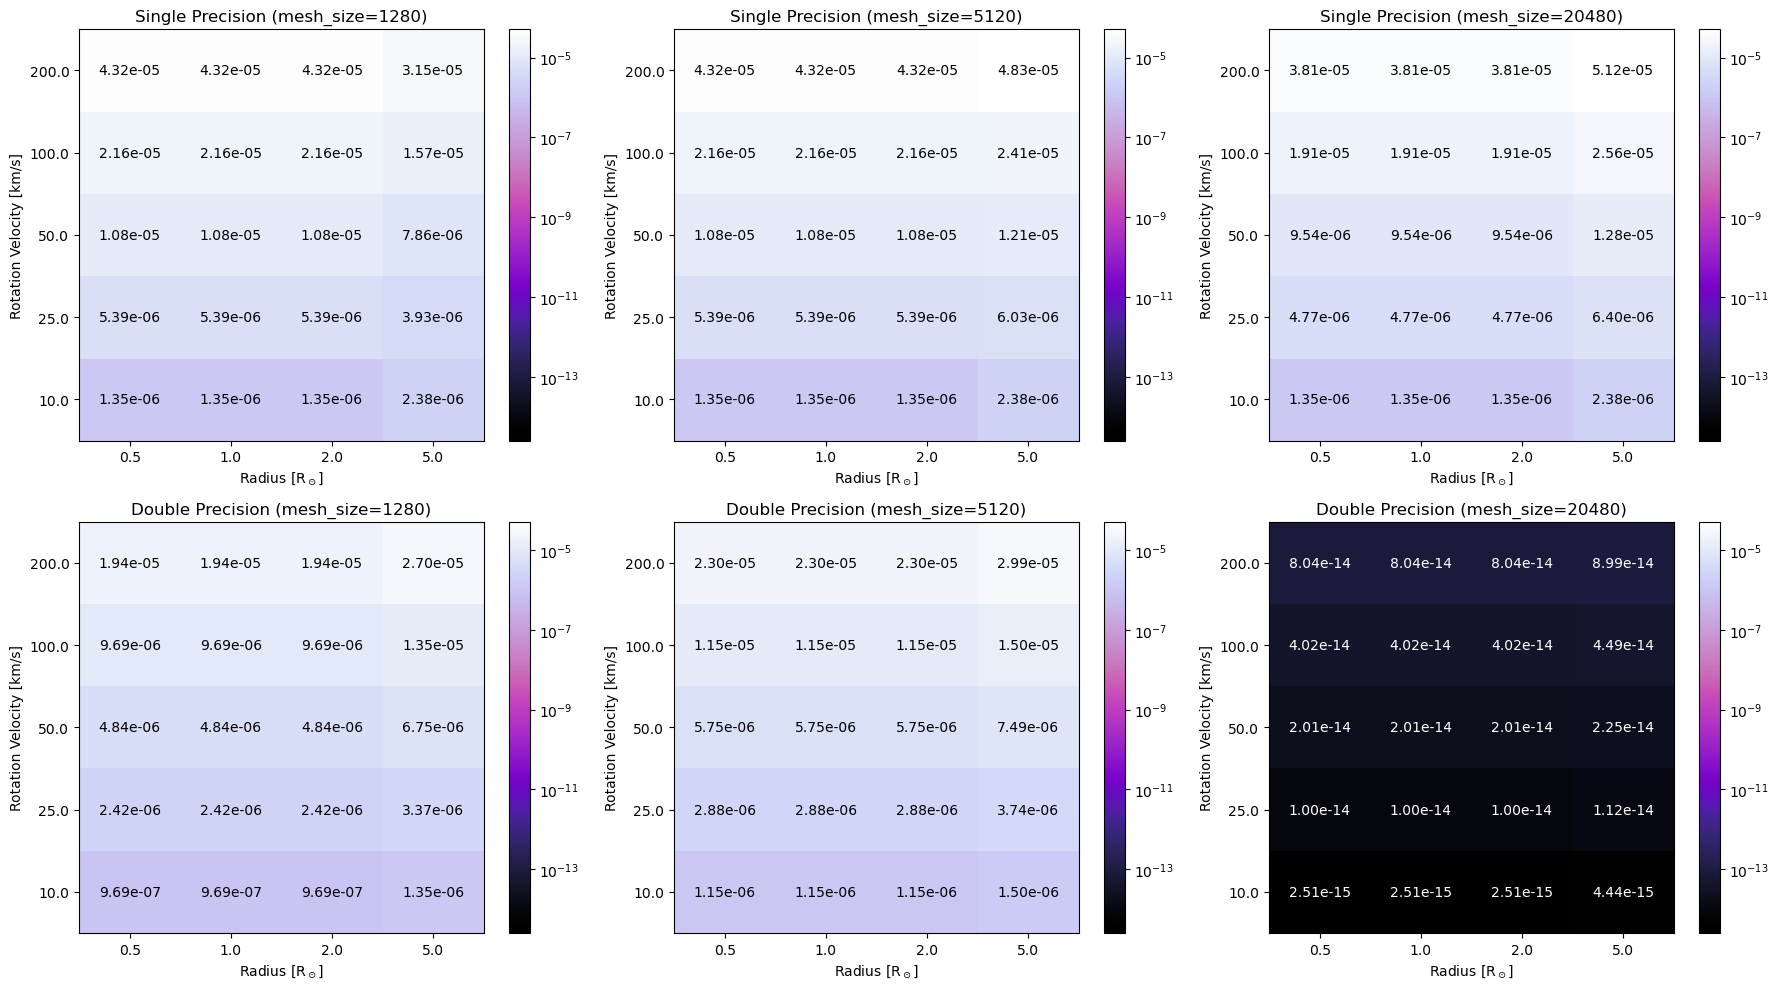

In [8]:
# Create pivot tables for heatmap - double precision
pivot_small = velocities_small.pivot(index='rotation_velocity', columns='radius', values='max_error')
pivot_medium = velocities_medium.pivot(index='rotation_velocity', columns='radius', values='max_error')
pivot_large = velocities_large.pivot(index='rotation_velocity', columns='radius', values='max_error')

# Create pivot tables for heatmap - single precision
pivot_small_sp = velocities_small_sp.pivot(index='rotation_velocity', columns='radius', values='max_error')
pivot_medium_sp = velocities_medium_sp.pivot(index='rotation_velocity', columns='radius', values='max_error')
pivot_large_sp = velocities_large_sp.pivot(index='rotation_velocity', columns='radius', values='max_error')

# Create figure with subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cmap = cmr.gothic

# Determine global min and max for consistent color scale across all 6 plots
vmin = min(
    pivot_small.values.min(), pivot_medium.values.min(), pivot_large.values.min(),
    pivot_small_sp.values.min(), pivot_medium_sp.values.min(), pivot_large_sp.values.min()
)
vmax = max(
    pivot_small.values.max(), pivot_medium.values.max(), pivot_large.values.max(),
    pivot_small_sp.values.max(), pivot_medium_sp.values.max(), pivot_large_sp.values.max()
)

# Create log normalization
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=vmin, vmax=vmax)

# First row: Single precision
im1 = axes[0, 0].imshow(pivot_small_sp, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[0, 0].set_title(f'Single Precision (mesh_size={velocities_small_sp["sample_count"].iloc[0]})')
axes[0, 0].set_xlabel(r'Radius [R$_\odot$]')
axes[0, 0].set_ylabel('Rotation Velocity [km/s]')
axes[0, 0].set_xticks(range(len(pivot_small_sp.columns)))
axes[0, 0].set_xticklabels(pivot_small_sp.columns)
axes[0, 0].set_yticks(range(len(pivot_small_sp.index)))
axes[0, 0].set_yticklabels(pivot_small_sp.index)
plt.colorbar(im1, ax=axes[0, 0])
# Add text annotations
for i in range(len(pivot_small_sp.index)):
    for j in range(len(pivot_small_sp.columns)):
        value = pivot_small_sp.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[0, 0].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

im2 = axes[0, 1].imshow(pivot_medium_sp, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[0, 1].set_title(f'Single Precision (mesh_size={velocities_medium_sp["sample_count"].iloc[0]})')
axes[0, 1].set_xlabel(r'Radius [R$_\odot$]')
axes[0, 1].set_ylabel('Rotation Velocity [km/s]')
axes[0, 1].set_xticks(range(len(pivot_medium_sp.columns)))
axes[0, 1].set_xticklabels(pivot_medium_sp.columns)
axes[0, 1].set_yticks(range(len(pivot_medium_sp.index)))
axes[0, 1].set_yticklabels(pivot_medium_sp.index)
plt.colorbar(im2, ax=axes[0, 1])
# Add text annotations
for i in range(len(pivot_medium_sp.index)):
    for j in range(len(pivot_medium_sp.columns)):
        value = pivot_medium_sp.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[0, 1].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

im3 = axes[0, 2].imshow(pivot_large_sp, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[0, 2].set_title(f'Single Precision (mesh_size={velocities_large_sp["sample_count"].iloc[0]})')
axes[0, 2].set_xlabel(r'Radius [R$_\odot$]')
axes[0, 2].set_ylabel('Rotation Velocity [km/s]')
axes[0, 2].set_xticks(range(len(pivot_large_sp.columns)))
axes[0, 2].set_xticklabels(pivot_large_sp.columns)
axes[0, 2].set_yticks(range(len(pivot_large_sp.index)))
axes[0, 2].set_yticklabels(pivot_large_sp.index)
plt.colorbar(im3, ax=axes[0, 2])
# Add text annotations
for i in range(len(pivot_large_sp.index)):
    for j in range(len(pivot_large_sp.columns)):
        value = pivot_large_sp.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[0, 2].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

# Second row: Double precision
im4 = axes[1, 0].imshow(pivot_small, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[1, 0].set_title(f'Double Precision (mesh_size={velocities_small["sample_count"].iloc[0]})')
axes[1, 0].set_xlabel(r'Radius [R$_\odot$]')
axes[1, 0].set_ylabel('Rotation Velocity [km/s]')
axes[1, 0].set_xticks(range(len(pivot_small.columns)))
axes[1, 0].set_xticklabels(pivot_small.columns)
axes[1, 0].set_yticks(range(len(pivot_small.index)))
axes[1, 0].set_yticklabels(pivot_small.index)
plt.colorbar(im4, ax=axes[1, 0])
# Add text annotations
for i in range(len(pivot_small.index)):
    for j in range(len(pivot_small.columns)):
        value = pivot_small.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[1, 0].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

im5 = axes[1, 1].imshow(pivot_medium, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[1, 1].set_title(f'Double Precision (mesh_size={velocities_medium["sample_count"].iloc[0]})')
axes[1, 1].set_xlabel(r'Radius [R$_\odot$]')
axes[1, 1].set_ylabel('Rotation Velocity [km/s]')
axes[1, 1].set_xticks(range(len(pivot_medium.columns)))
axes[1, 1].set_xticklabels(pivot_medium.columns)
axes[1, 1].set_yticks(range(len(pivot_medium.index)))
axes[1, 1].set_yticklabels(pivot_medium.index)
plt.colorbar(im5, ax=axes[1, 1])
# Add text annotations
for i in range(len(pivot_medium.index)):
    for j in range(len(pivot_medium.columns)):
        value = pivot_medium.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[1, 1].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

im6 = axes[1, 2].imshow(pivot_large, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[1, 2].set_title(f'Double Precision (mesh_size={velocities_large["sample_count"].iloc[0]})')
axes[1, 2].set_xlabel(r'Radius [R$_\odot$]')
axes[1, 2].set_ylabel('Rotation Velocity [km/s]')
axes[1, 2].set_xticks(range(len(pivot_large.columns)))
axes[1, 2].set_xticklabels(pivot_large.columns)
axes[1, 2].set_yticks(range(len(pivot_large.index)))
axes[1, 2].set_yticklabels(pivot_large.index)
plt.colorbar(im6, ax=axes[1, 2])
# Add text annotations
for i in range(len(pivot_large.index)):
    for j in range(len(pivot_large.columns)):
        value = pivot_large.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[1, 2].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
np.log10(vmax)/2

-2.1454518392295086

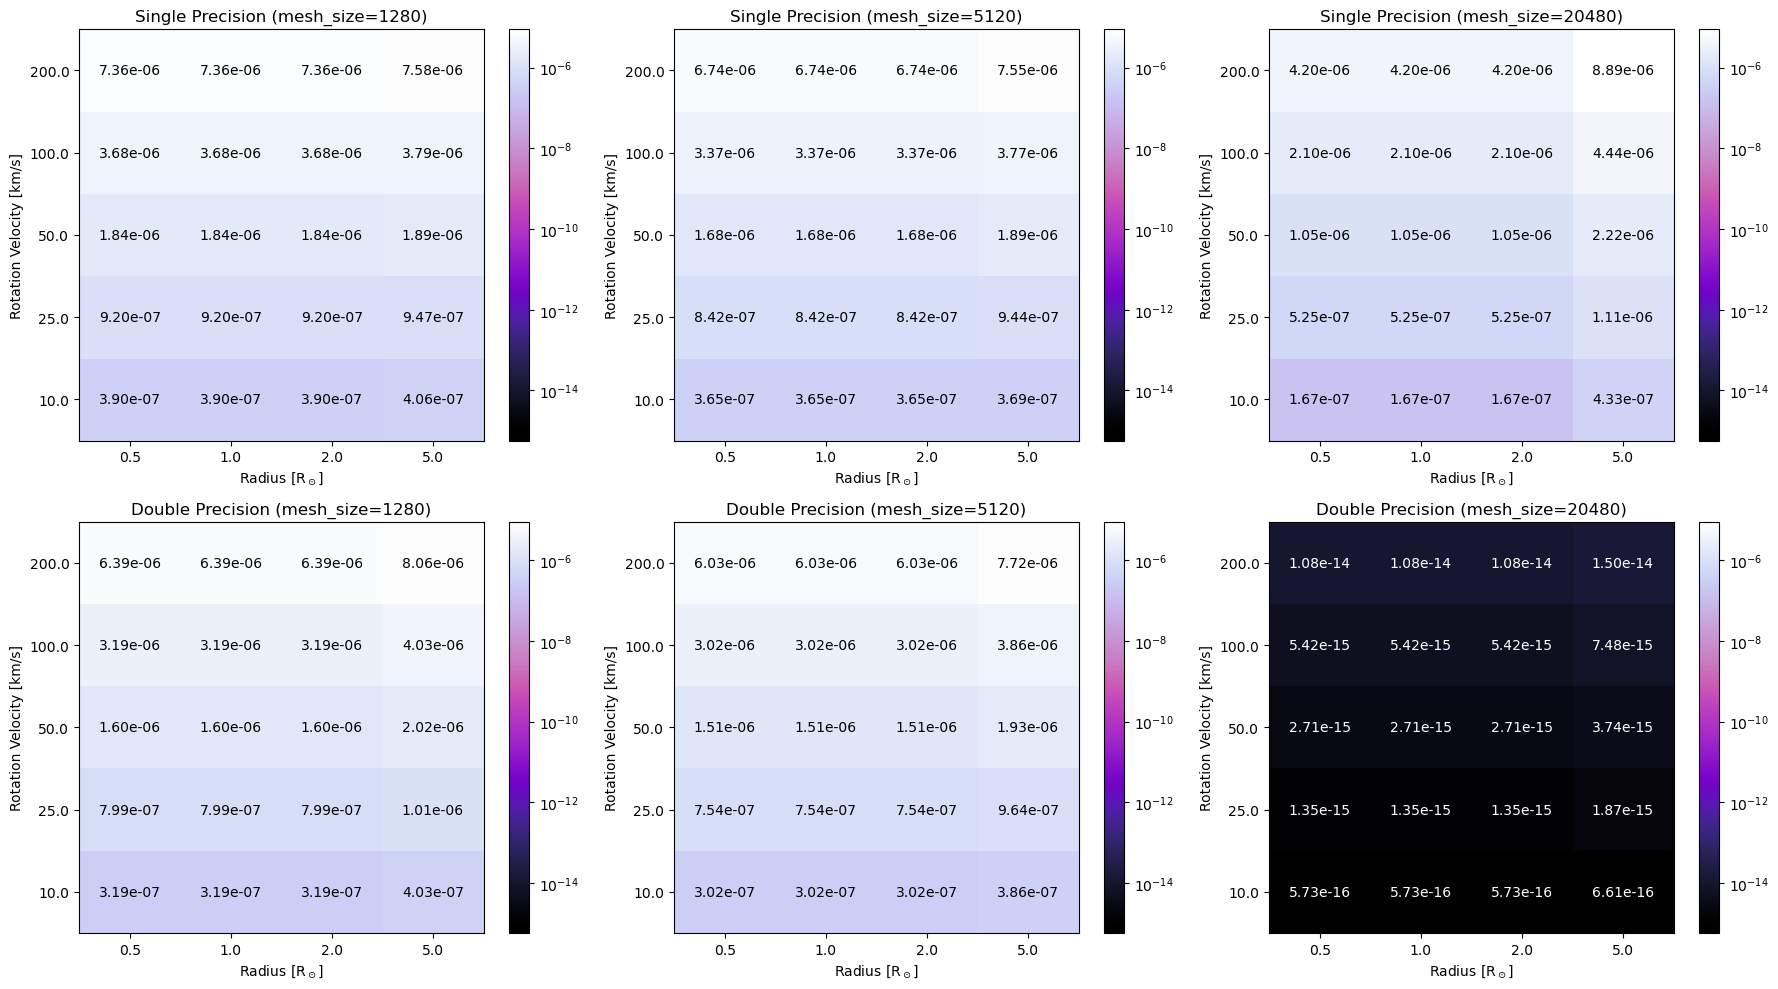

In [10]:
# Create pivot tables for heatmap - double precision
pivot_small = velocities_small.pivot(index='rotation_velocity', columns='radius', values='mean_error')
pivot_medium = velocities_medium.pivot(index='rotation_velocity', columns='radius', values='mean_error')
pivot_large = velocities_large.pivot(index='rotation_velocity', columns='radius', values='mean_error')

# Create pivot tables for heatmap - single precision
pivot_small_sp = velocities_small_sp.pivot(index='rotation_velocity', columns='radius', values='mean_error')
pivot_medium_sp = velocities_medium_sp.pivot(index='rotation_velocity', columns='radius', values='mean_error')
pivot_large_sp = velocities_large_sp.pivot(index='rotation_velocity', columns='radius', values='mean_error')

# Create figure with subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cmap = cmr.gothic

# Determine global min and max for consistent color scale across all 6 plots
vmin = min(
    pivot_small.values.min(), pivot_medium.values.min(), pivot_large.values.min(),
    pivot_small_sp.values.min(), pivot_medium_sp.values.min(), pivot_large_sp.values.min()
)
vmax = max(
    pivot_small.values.max(), pivot_medium.values.max(), pivot_large.values.max(),
    pivot_small_sp.values.max(), pivot_medium_sp.values.max(), pivot_large_sp.values.max()
)

# Create log normalization
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=vmin, vmax=vmax)

# First row: Single precision
im1 = axes[0, 0].imshow(pivot_small_sp, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[0, 0].set_title(f'Single Precision (mesh_size={velocities_small_sp["sample_count"].iloc[0]})')
axes[0, 0].set_xlabel(r'Radius [R$_\odot$]')
axes[0, 0].set_ylabel('Rotation Velocity [km/s]')
axes[0, 0].set_xticks(range(len(pivot_small_sp.columns)))
axes[0, 0].set_xticklabels(pivot_small_sp.columns)
axes[0, 0].set_yticks(range(len(pivot_small_sp.index)))
axes[0, 0].set_yticklabels(pivot_small_sp.index)
plt.colorbar(im1, ax=axes[0, 0])
# Add text annotations
for i in range(len(pivot_small_sp.index)):
    for j in range(len(pivot_small_sp.columns)):
        value = pivot_small_sp.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[0, 0].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

im2 = axes[0, 1].imshow(pivot_medium_sp, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[0, 1].set_title(f'Single Precision (mesh_size={velocities_medium_sp["sample_count"].iloc[0]})')
axes[0, 1].set_xlabel(r'Radius [R$_\odot$]')
axes[0, 1].set_ylabel('Rotation Velocity [km/s]')
axes[0, 1].set_xticks(range(len(pivot_medium_sp.columns)))
axes[0, 1].set_xticklabels(pivot_medium_sp.columns)
axes[0, 1].set_yticks(range(len(pivot_medium_sp.index)))
axes[0, 1].set_yticklabels(pivot_medium_sp.index)
plt.colorbar(im2, ax=axes[0, 1])
# Add text annotations
for i in range(len(pivot_medium_sp.index)):
    for j in range(len(pivot_medium_sp.columns)):
        value = pivot_medium_sp.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[0, 1].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

im3 = axes[0, 2].imshow(pivot_large_sp, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[0, 2].set_title(f'Single Precision (mesh_size={velocities_large_sp["sample_count"].iloc[0]})')
axes[0, 2].set_xlabel(r'Radius [R$_\odot$]')
axes[0, 2].set_ylabel('Rotation Velocity [km/s]')
axes[0, 2].set_xticks(range(len(pivot_large_sp.columns)))
axes[0, 2].set_xticklabels(pivot_large_sp.columns)
axes[0, 2].set_yticks(range(len(pivot_large_sp.index)))
axes[0, 2].set_yticklabels(pivot_large_sp.index)
plt.colorbar(im3, ax=axes[0, 2])
# Add text annotations
for i in range(len(pivot_large_sp.index)):
    for j in range(len(pivot_large_sp.columns)):
        value = pivot_large_sp.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[0, 2].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

# Second row: Double precision
im4 = axes[1, 0].imshow(pivot_small, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[1, 0].set_title(f'Double Precision (mesh_size={velocities_small["sample_count"].iloc[0]})')
axes[1, 0].set_xlabel(r'Radius [R$_\odot$]')
axes[1, 0].set_ylabel('Rotation Velocity [km/s]')
axes[1, 0].set_xticks(range(len(pivot_small.columns)))
axes[1, 0].set_xticklabels(pivot_small.columns)
axes[1, 0].set_yticks(range(len(pivot_small.index)))
axes[1, 0].set_yticklabels(pivot_small.index)
plt.colorbar(im4, ax=axes[1, 0])
# Add text annotations
for i in range(len(pivot_small.index)):
    for j in range(len(pivot_small.columns)):
        value = pivot_small.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[1, 0].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

im5 = axes[1, 1].imshow(pivot_medium, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[1, 1].set_title(f'Double Precision (mesh_size={velocities_medium["sample_count"].iloc[0]})')
axes[1, 1].set_xlabel(r'Radius [R$_\odot$]')
axes[1, 1].set_ylabel('Rotation Velocity [km/s]')
axes[1, 1].set_xticks(range(len(pivot_medium.columns)))
axes[1, 1].set_xticklabels(pivot_medium.columns)
axes[1, 1].set_yticks(range(len(pivot_medium.index)))
axes[1, 1].set_yticklabels(pivot_medium.index)
plt.colorbar(im5, ax=axes[1, 1])
# Add text annotations
for i in range(len(pivot_medium.index)):
    for j in range(len(pivot_medium.columns)):
        value = pivot_medium.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[1, 1].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

im6 = axes[1, 2].imshow(pivot_large, aspect='auto', cmap=cmap, origin='lower', norm=norm)
axes[1, 2].set_title(f'Double Precision (mesh_size={velocities_large["sample_count"].iloc[0]})')
axes[1, 2].set_xlabel(r'Radius [R$_\odot$]')
axes[1, 2].set_ylabel('Rotation Velocity [km/s]')
axes[1, 2].set_xticks(range(len(pivot_large.columns)))
axes[1, 2].set_xticklabels(pivot_large.columns)
axes[1, 2].set_yticks(range(len(pivot_large.index)))
axes[1, 2].set_yticklabels(pivot_large.index)
plt.colorbar(im6, ax=axes[1, 2])
# Add text annotations
for i in range(len(pivot_large.index)):
    for j in range(len(pivot_large.columns)):
        value = pivot_large.iloc[i, j]
        text_color = "white" if np.log10(value) < (np.log10(vmin) + np.log10(vmax))/2 else "black"
        text = axes[1, 2].text(j, i, f'{value:.2e}',
                           ha="center", va="center", color=text_color, fontsize=10)

plt.tight_layout()
plt.show()